['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Slope: 0.25797761849057654
Intercept: 0.4850206129374197
MSE: 1.6449229482854868
R2: -0.2552744796465303
Intercept: 1.6547622685968644
Slope: 0.07675558963126285
MSE: 1.2923314440807283
R2: 0.013795337532286012


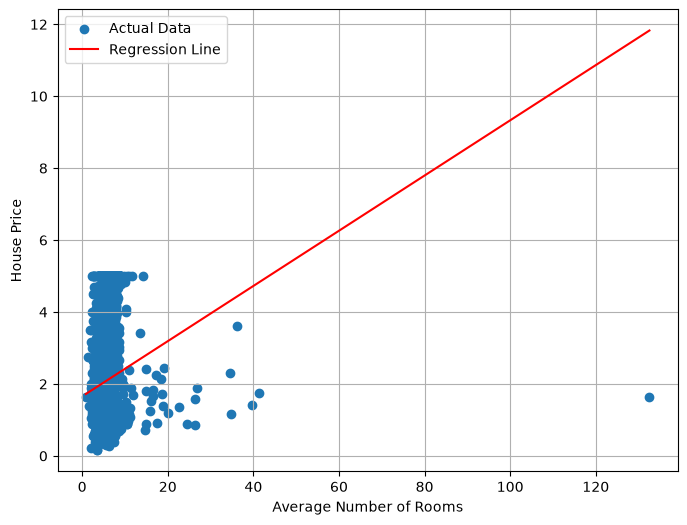

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

housing=fetch_california_housing()
print(housing.feature_names)

X=housing.data[:,2]
y=housing.target
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

"""## Gradient Descent"""

m=0
c=0
learning_rate=0.001
epochs=1000
n=len(X_train)
for i in range(epochs):
    y_pred=m*X_train+c
    dm=(-2/n)*np.sum(X_train*(y_train-y_pred))
    dc=(-2/n)*np.sum(y_train-y_pred)
    m-=learning_rate*dm
    c-=learning_rate*dc
y_pred_gd=m*X_test+c
print("Slope:",m)
print("Intercept:",c)
print("MSE:",mean_squared_error(y_test,y_pred_gd))
print("R2:",r2_score(y_test,y_pred_gd))

"""## Normal Equation"""

ones=np.ones(len(X_train))
X_matrix=np.column_stack((ones,X_train))
theta=np.linalg.inv(X_matrix.T@X_matrix)@(X_matrix.T@y_train)
ones_test=np.ones(len(X_test))
X_test_matrix=np.column_stack((ones_test,X_test))
y_pred=X_test_matrix@theta
print("Intercept:",theta[0])
print("Slope:",theta[1])
print("MSE:",mean_squared_error(y_test,y_pred))
print("R2:",r2_score(y_test,y_pred))

"""## Visualization"""

plt.figure(figsize=(8,6))
plt.scatter(X_test,y_test,label='Actual Data')
x_line=np.linspace(min(X_test),max(X_test),100)
plt.plot(x_line,theta[0]+theta[1]*x_line,color='red',label='Regression Line')
plt.xlabel('Average Number of Rooms')
plt.ylabel('House Price')
plt.legend()
plt.grid(True)
plt.show()

